In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ================================================================
# 🔹 LOAD DATA
# ================================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/SER_Project/"

X = np.load(DATA_PATH + "X_eyase.npy")   # (579, 80000)
y = np.load(DATA_PATH + "y_eyase.npy")

print("Loaded:", X.shape, y.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (579, 80000) (579,)


Converting to spectrograms...
New shape: (579, 128, 128)
Train: (405, 128, 128)
Val  : (87, 128, 128)
Test : (87, 128, 128)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 128, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,740 (518.52 KB)

 Trainable params: 132,740 (518.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - accuracy: 0.2667 - loss: 1.4672 - val_accuracy: 0.2529 - val_loss: 1.4075
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.2296 - loss: 1.4033 - val_accuracy: 0.2644 - val_loss: 1.3890
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.2420 - loss: 1.4007 - val_accuracy: 0.2529 - val_loss: 1.3884
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - accuracy: 0.2148 - loss: 1.4014 - val_accuracy: 0.2299 - val_loss: 1.3921
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.2494 - loss: 1.3993 - val_accuracy: 0.2644 - val_loss: 1.3829
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 389ms/step - accuracy: 0.2617 - loss: 1.3919 - val_accuracy: 0.2529 - val_loss: 1.3936
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.2543 - loss: 1.4021 - val_accuracy: 0.2529 - val_loss: 1.3840
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.2642 - loss: 1.3860 - val_accuracy: 0.2299 - val_loss

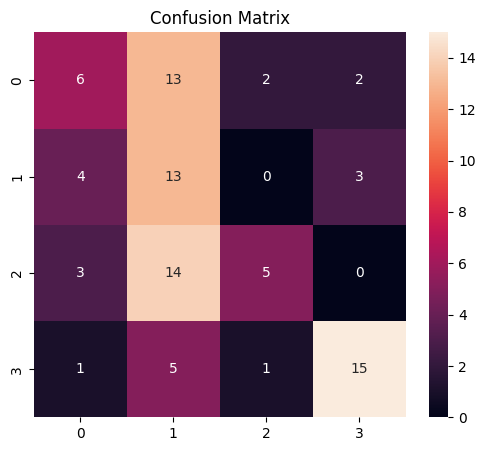

In [ ]:
# ================================================================
# 🔹 CONVERT WAV → MEL SPECTROGRAM (FIX)
# ================================================================
def wav_to_mel(wav, sr=16000, n_mels=128, max_len=128):
    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel)

    # (mel, time) → (time, mel)
    mel_db = mel_db.T

    # pad / truncate to 128 frames
    if mel_db.shape[0] < max_len:
        mel_db = np.pad(mel_db, ((0, max_len - mel_db.shape[0]), (0, 0)))
    else:
        mel_db = mel_db[:max_len]

    return mel_db


print("Converting to spectrograms...")

X_spec = np.array([wav_to_mel(x) for x in X], dtype=np.float32)

print("New shape:", X_spec.shape)   # (579, 128, 128)

# ================================================================
# 🔹 NORMALIZE
# ================================================================
X_spec = (X_spec - X_spec.min()) / (X_spec.max() - X_spec.min() + 1e-8)

# ================================================================
# 🔹 SPLIT
# ================================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X_spec, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# ================================================================
# 🔹 CLASS WEIGHTS
# ================================================================
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

# ================================================================
# 🔹 MODEL
# ================================================================
NUM_CLASSES = len(np.unique(y))

inp = keras.Input(shape=(128, 128))

x = layers.Conv1D(64, 3, padding="same")(inp)
x = layers.LayerNormalization()(x)
x = layers.Activation("gelu")(x)

x = layers.Conv1D(128, 3, padding="same")(x)
x = layers.LayerNormalization()(x)
x = layers.Activation("gelu")(x)

x = layers.MaxPooling1D(2)(x)

x = layers.Bidirectional(
    layers.GRU(64, return_sequences=False)
)(x)

x = layers.Dense(64, activation="gelu")(x)
x = layers.Dropout(0.3)(x)

out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inp, out)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ================================================================
# 🔹 TRAIN
# ================================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights
)

# ================================================================
# 🔹 EVALUATION
# ================================================================
loss, acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

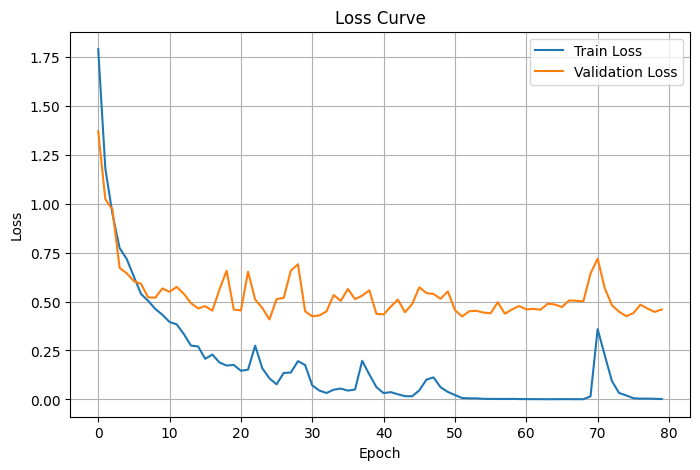

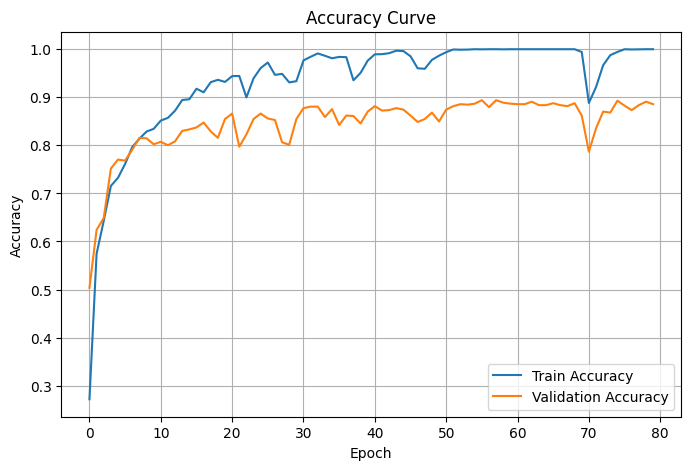

In [9]:
# ================================================================
# 🔹 TRAINING CURVES (LOSS + ACCURACY)
# ================================================================

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()